In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import anndata as ad
import math
import csv
from matplotlib import cm

In [2]:
with open('../../parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [3]:
sam = SAM()
sam.load_data('../../Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_03122205.h5ad')
gene_dict = {}
for i in range(len(sam.adata.var_names)):
    gene_dict[sam.adata.var_names[i]] = i
gene_dict['NaN'] = 'NaN'

In [4]:
org = 'XT'

In [5]:
sam.adata.obs.columns

Index(['n_genes', 'n_counts', 'key', 'leiden_clusters', 'eq_subclass',
       'eq_subclass_lc', 'eq_subclass_frac', 'eq_subclass_nounlabeled',
       'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nnm',
       'eq_subclass_nounlabeled_nmm', 'neurotransmitter',
       'ss_subclass_nounlabeled', 'ss_subclass_v2_nounlabeled',
       'ss_subclass_v3_nounlabeled', 'ss_subclass_nounlabeled_nmm',
       'ss_subclass', 'ss_subclass_nounlabeled_nmm_micro',
       'ss_subclass_nounlabeled_nmm_v2', 'ss_subclass_nounlabeled_nmm_v2_nn',
       'ss_subclass_nounlabeled_nmm_v3_nn', 'neurotransmitter_v2', 'test',
       'ss_subclass_old', 'ss_subclass_v4_nounlabeled',
       'ss_subclass_v4_nounlabeled_nn', 'ss_subclass_nounlabeled_nmm_v4_nn',
       'ss_subclass_nounlabeled_nmm_cl_v4_nn', 'neurotransmitter_v3'],
      dtype='object')

In [6]:
level = 'ss_subclass_nounlabeled_nmm_cl_v4_nn'

In [7]:
for item in sam.adata.obs[level].unique():
    if item[-2:] == 'NN':
        parent_dict[item] = 'not hypo'
    if item[:2] == 'xt':
        parent_dict[item] = 'hypo'
    if item[:2] == 'cj':
        parent_dict[item] = 'hypo'
    if item[:2] == 'ac':
        parent_dict[item] = 'hypo'
    if item[:2] == 'dr':
        parent_dict[item] = 'hypo'
    if item[:2] == 'mo':
        parent_dict[item] = 'hypo'
    if item[:2] == 'mg':
        parent_dict[item] = 'hypo'
        
parent_dict['hypo'] = 'hypo'
parent_dict['not hypo'] = 'not hypo'
parent_dict['NN_unknown'] = 'not hypo'

In [8]:
hl = []
for item in sam.adata.obs[level].unique():
    if parent_dict[parent_dict[item]] == 'hypo':
        hl.append(item)

In [9]:
hl

['088 BST Tac2 Gaba',
 '140 PMd-LHA Foxb1 Glut',
 '141 PH-SUM Foxa1 Glut',
 '097 PVHd-SBPV Six3 Prox1 Gaba',
 '115 MS-SF Bsx Glut',
 'xt_4',
 'xt_17',
 '129 VMH Nr5a1 Glut',
 '101 ZI Pax6 Gaba',
 '139 PH-LHA Foxb1 Glut',
 'xt_16',
 '100 AHN Onecut3 Gaba',
 'cj_ac_xt_1',
 '092 TMv-PMv Tbx3 Hist-Gaba',
 'ac_xt_1',
 '103 PVHd-DMH Lhx6 Gaba',
 '102 DMH-LHA Gsx1 Gaba',
 '131 LHA-AHN-PVH Otp Trh Glut',
 '126 ARH-PVp Tbx3 Glut',
 '118 ADP-MPO Trp73 Glut',
 '098 AHN-SBPV-PVHd Pdrm12 Gaba',
 '138 PH Pitx2 Glut',
 '107 DMH Hmx2 Gaba',
 '085 SI-MPO-LPO Lhx8 Gaba',
 '106 PVpo-VMPO-MPN Hmx2 Gaba',
 'cj_xt_dr_1',
 'xt_14',
 'xt_12',
 '135 STN-PSTN Pitx2 Glut',
 '094 SCH Six6 Cdc14a Gaba',
 '104 TU-ARH Otp Six6 Gaba',
 'xt_8',
 '132 AHN-RCH-LHA Otp Fezf1 Glut',
 '125 DMH Hmx2 Glut',
 'cj_ac_xt_dr_4',
 'cj_ac_xt_dr_1',
 '079 CEA-BST Six3 Cyp26b1 Gaba',
 'cj_xt_dr_2',
 '127 DMH-LHA Vgll2 Glut',
 '074 MEA-BST Lhx6 Sp9 Gaba',
 '090 BST-MPN Six3 Nrgn Gaba',
 '136 PMv-TMv Pitx2 Glut',
 'xt_40',
 'xt_11',
 

In [10]:
tot_neuropep = pd.read_csv('../../Neuropeptides_receptors_10202025.csv')

In [11]:
mg_neuropep = list(pd.read_csv('../../mg_np_all_08022026.csv').columns)

In [12]:
#update this to match order of NP in organism from figure 2B
neuropep = list(pd.read_csv("../../xt_np_all_08022026.csv").columns)

In [13]:
for i, val in enumerate(neuropep):
    if val not in gene_dict:
        neuropep[i] = 'nan'

In [14]:
R_set = set(tot_neuropep.columns) - set(['Neuropeptide names'])

In [15]:
receptors = set(np.unique([str(x).strip() for x in tot_neuropep[R_set].values.ravel() if pd.notna(x)]))

In [16]:
receptors = list(receptors)
neuropeptides = list(set(tot_neuropep['Neuropeptide names']))

In [17]:
len(neuropeptides)

94

In [18]:
len(receptors)

92

In [19]:
gi = [gene_dict[i] if i != 'nan' else np.nan for i in neuropep]

In [20]:
exp_array = np.zeros((len(sam.adata),len(gi))) 
tot_exp = sam.adata.X.A
for i in range(len(gi)):
    if ~np.isnan(gi[i]):
        exp_array[:,i] = tot_exp[:,gi[i]]
    else:
        exp_array[:,i] = np.nan

In [21]:
ct_array = np.zeros((len(hl), len(gi)))
ordered_names = []
for i in range(len(hl)):
    ct_array[i,:] = np.average(exp_array[sam.adata.obs[level] == hl[i]], axis = 0)
    ordered_names.append(hl[i])

In [22]:
col_min = ct_array.min(axis=0, keepdims=True)
col_max = ct_array.max(axis=0, keepdims=True)
norm_ct_array = (ct_array - col_min) / (col_max - col_min)

/scratch/miniconda/lib/python3.7/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in true_divide
  This is separate from the ipykernel package so we can avoid doing imports until


In [23]:
df_norm  = pd.DataFrame(norm_ct_array, index = ordered_names, columns = mg_neuropep)

In [24]:
df_norm = df_norm.sort_index()

In [25]:
df_norm.shape

(85, 143)

In [26]:
df_norm.loc[:,'Pomc']

073 MEA-BST Sox6 Gaba            0.132772
074 MEA-BST Lhx6 Sp9 Gaba        0.124194
079 CEA-BST Six3 Cyp26b1 Gaba    0.254109
082 CEA-BST Ebf1 Pdyn Gaba       0.217178
085 SI-MPO-LPO Lhx8 Gaba         0.183748
                                   ...   
xt_42                            0.019350
xt_7                             0.133846
xt_8                             0.201531
xt_9                             0.169310
xt_m098_m104                     0.185470
Name: Pomc, Length: 85, dtype: float64

In [27]:
mouse_mapping = [i for i in df_norm.index if i[:3].isdigit()] 

In [28]:
mouse_mapping, len(mouse_mapping)

(['073 MEA-BST Sox6 Gaba',
  '074 MEA-BST Lhx6 Sp9 Gaba',
  '079 CEA-BST Six3 Cyp26b1 Gaba',
  '082 CEA-BST Ebf1 Pdyn Gaba',
  '085 SI-MPO-LPO Lhx8 Gaba',
  '086 MPO-ADP Lhx8 Gaba',
  '088 BST Tac2 Gaba',
  '090 BST-MPN Six3 Nrgn Gaba',
  '091 ARH-PVi Six6 Dopa-Gaba',
  '092 TMv-PMv Tbx3 Hist-Gaba',
  '093 RT-ZI Gnb3 Gaba',
  '094 SCH Six6 Cdc14a Gaba',
  '097 PVHd-SBPV Six3 Prox1 Gaba',
  '098 AHN-SBPV-PVHd Pdrm12 Gaba',
  '100 AHN Onecut3 Gaba',
  '101 ZI Pax6 Gaba',
  '102 DMH-LHA Gsx1 Gaba',
  '103 PVHd-DMH Lhx6 Gaba',
  '104 TU-ARH Otp Six6 Gaba',
  '105 TMd-DMH Foxd2 Gaba',
  '106 PVpo-VMPO-MPN Hmx2 Gaba',
  '107 DMH Hmx2 Gaba',
  '108 ARH-PVp Tbx3 Gaba',
  '111 TRS-BAC Sln Glut',
  '115 MS-SF Bsx Glut',
  '118 ADP-MPO Trp73 Glut',
  '119 SI-MA-LPO-LHA Skor1 Glut',
  '122 LHA-MEA Otp Glut',
  '124 MPN-MPO-PVpo Hmx2 Glut',
  '125 DMH Hmx2 Glut',
  '126 ARH-PVp Tbx3 Glut',
  '127 DMH-LHA Vgll2 Glut',
  '129 VMH Nr5a1 Glut',
  '130 LHA Pmch Glut',
  '131 LHA-AHN-PVH Otp Trh Glut',
 

In [29]:
df_norm = df_norm.loc[mouse_mapping,:]

In [30]:
reindex_np = ['Grp',
 'Nts',
 'Pnoc',
 'Gal',
 'Agrp',
 'Npy',
 'Sst',
 'Crh',
 'Avp',
 'Oxt',
 'Trh',
 'Pmch',
 'Igf1',
 'Pdyn',
 'Adcyap1',
 'Qrfp',
 'Npvf',
 'Hcrt',
 'Pomc']

In [31]:
reindex_npr = ['Galr1','Glp1r','Agtr1a','Oprk1']

In [32]:
neuropeptides = np.sort(neuropeptides)
receptors = np.sort(receptors)

In [33]:
neuropeptides

array(['Adcyap1', 'Adipoq', 'Adm', 'Adm2', 'Agrp', 'Agt', 'Apln', 'Avp',
       'Calca', 'Calcb', 'Cartpt', 'Cck', 'Cgrp', 'Chga', 'Cort', 'Crh',
       'Dbi', 'Edn1', 'Edn2', 'Edn3', 'Enho', 'Gal', 'Galp', 'Gast',
       'Gcg', 'Ghrh', 'Ghrl', 'Gip', 'Glp', 'Gnas', 'Gnrh1', 'Gnrh2',
       'Grp', 'Hcrt', 'Iapp', 'Igf1', 'Igf2', 'Igf3', 'Ins1', 'Ins2',
       'Insl3', 'Kiss1', 'Kiss2', 'Kng1', 'Lep', 'Mln', 'Nmb', 'Nms',
       'Nmu', 'Npb', 'Npff', 'Nppa', 'Nppb', 'Nppc', 'Nps', 'Npvf', 'Npw',
       'Npy', 'Nts', 'Nucb2', 'Oxt', 'Pcsk1n', 'Pdyn', 'Penk', 'Pmch',
       'Pnoc', 'Pomc', 'Ppy', 'Prl', 'Prlh', 'Prok1', 'Prok2', 'Pthlh',
       'Qrfp', 'Retn', 'Retnla', 'Retnlb', 'Retnlg', 'Rln1', 'Rln2',
       'Rln3', 'Sct', 'Sst', 'Tac1', 'Tac2', 'Tac3', 'Trh', 'Ucn', 'Ucn2',
       'Ucn3', 'Uts2', 'Uts2b', 'Vgf', 'Vip'], dtype='<U7')

In [34]:
for item in neuropeptides:
    if item not in reindex_np and item in df_norm.columns:
        reindex_np.append(item)

In [35]:
for item in receptors:
    if item not in reindex_npr and item in df_norm.columns:
        reindex_npr.append(item)

In [36]:
df_norm_np = df_norm.loc[:,reindex_np]

In [37]:
df_norm_npr = df_norm.loc[:,reindex_npr]

In [38]:
len(df_norm_np.index)

45

In [39]:
len(df_norm_np.columns)

63

In [40]:
len(df_norm_npr.columns)

80

In [41]:
df_norm_np.columns

Index(['Grp', 'Nts', 'Pnoc', 'Gal', 'Agrp', 'Npy', 'Sst', 'Crh', 'Avp', 'Oxt',
       'Trh', 'Pmch', 'Igf1', 'Pdyn', 'Adcyap1', 'Qrfp', 'Npvf', 'Hcrt',
       'Pomc', 'Adipoq', 'Adm', 'Adm2', 'Agt', 'Apln', 'Calca', 'Cartpt',
       'Cck', 'Chga', 'Dbi', 'Edn1', 'Edn2', 'Edn3', 'Gcg', 'Ghrl', 'Gip',
       'Gnas', 'Gnrh1', 'Iapp', 'Igf2', 'Ins2', 'Kng1', 'Lep', 'Nmu', 'Npb',
       'Npff', 'Nppc', 'Nps', 'Npw', 'Nucb2', 'Penk', 'Prl', 'Prok1', 'Prok2',
       'Pthlh', 'Rln3', 'Tac1', 'Tac2', 'Ucn', 'Ucn3', 'Uts2', 'Uts2b', 'Vgf',
       'Vip'],
      dtype='object')

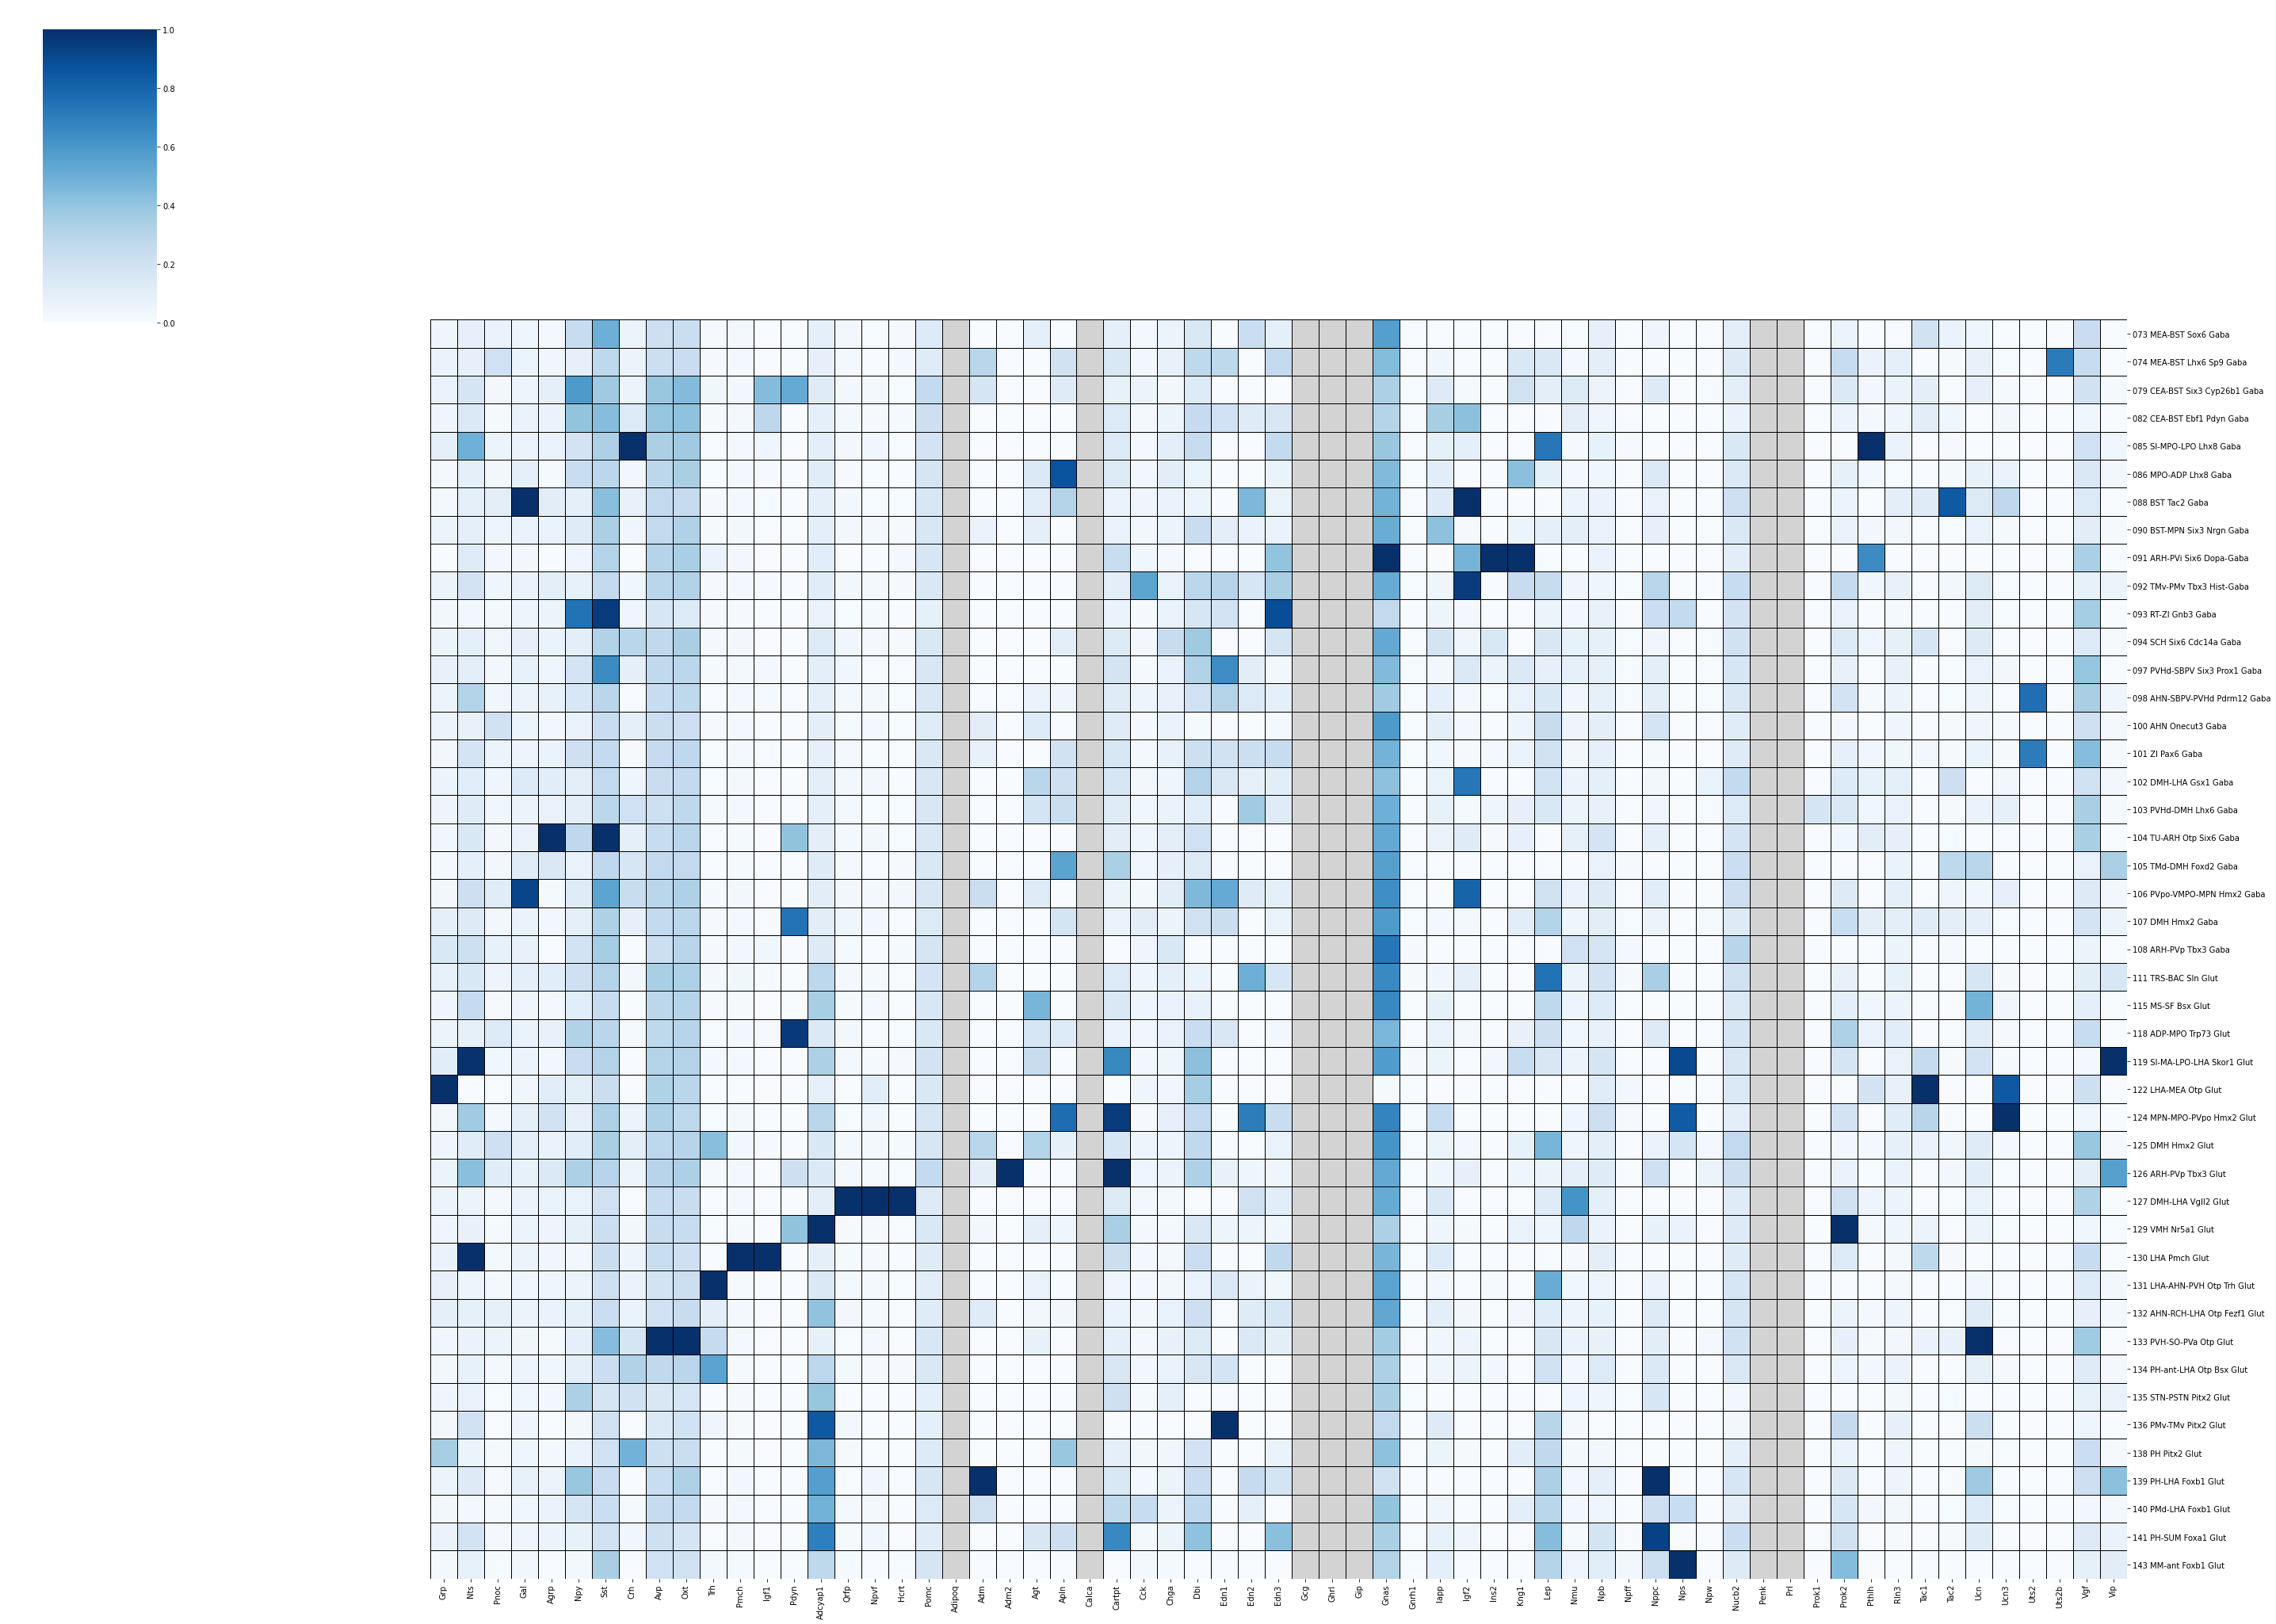

In [42]:
cmap = cm.get_cmap("Blues").copy()
cmap.set_bad(color="lightgrey") 
g = sns.clustermap(df_norm_np, cmap = cmap,linewidth=.5,linecolor = 'black', row_cluster = False, col_cluster = False,
              figsize = (40,(40*df_norm_np.shape[0])/df_norm_np.shape[1]))
#plt.savefig('../../Figures/Figures_08022026/'+org+'_neuropep_mappedhypo_neurons_08042026.pdf')
#plt.savefig('../../Figures/Figures_08022026/'+org+'_neuropep_mappedhypo_neurons_08042026.svg')

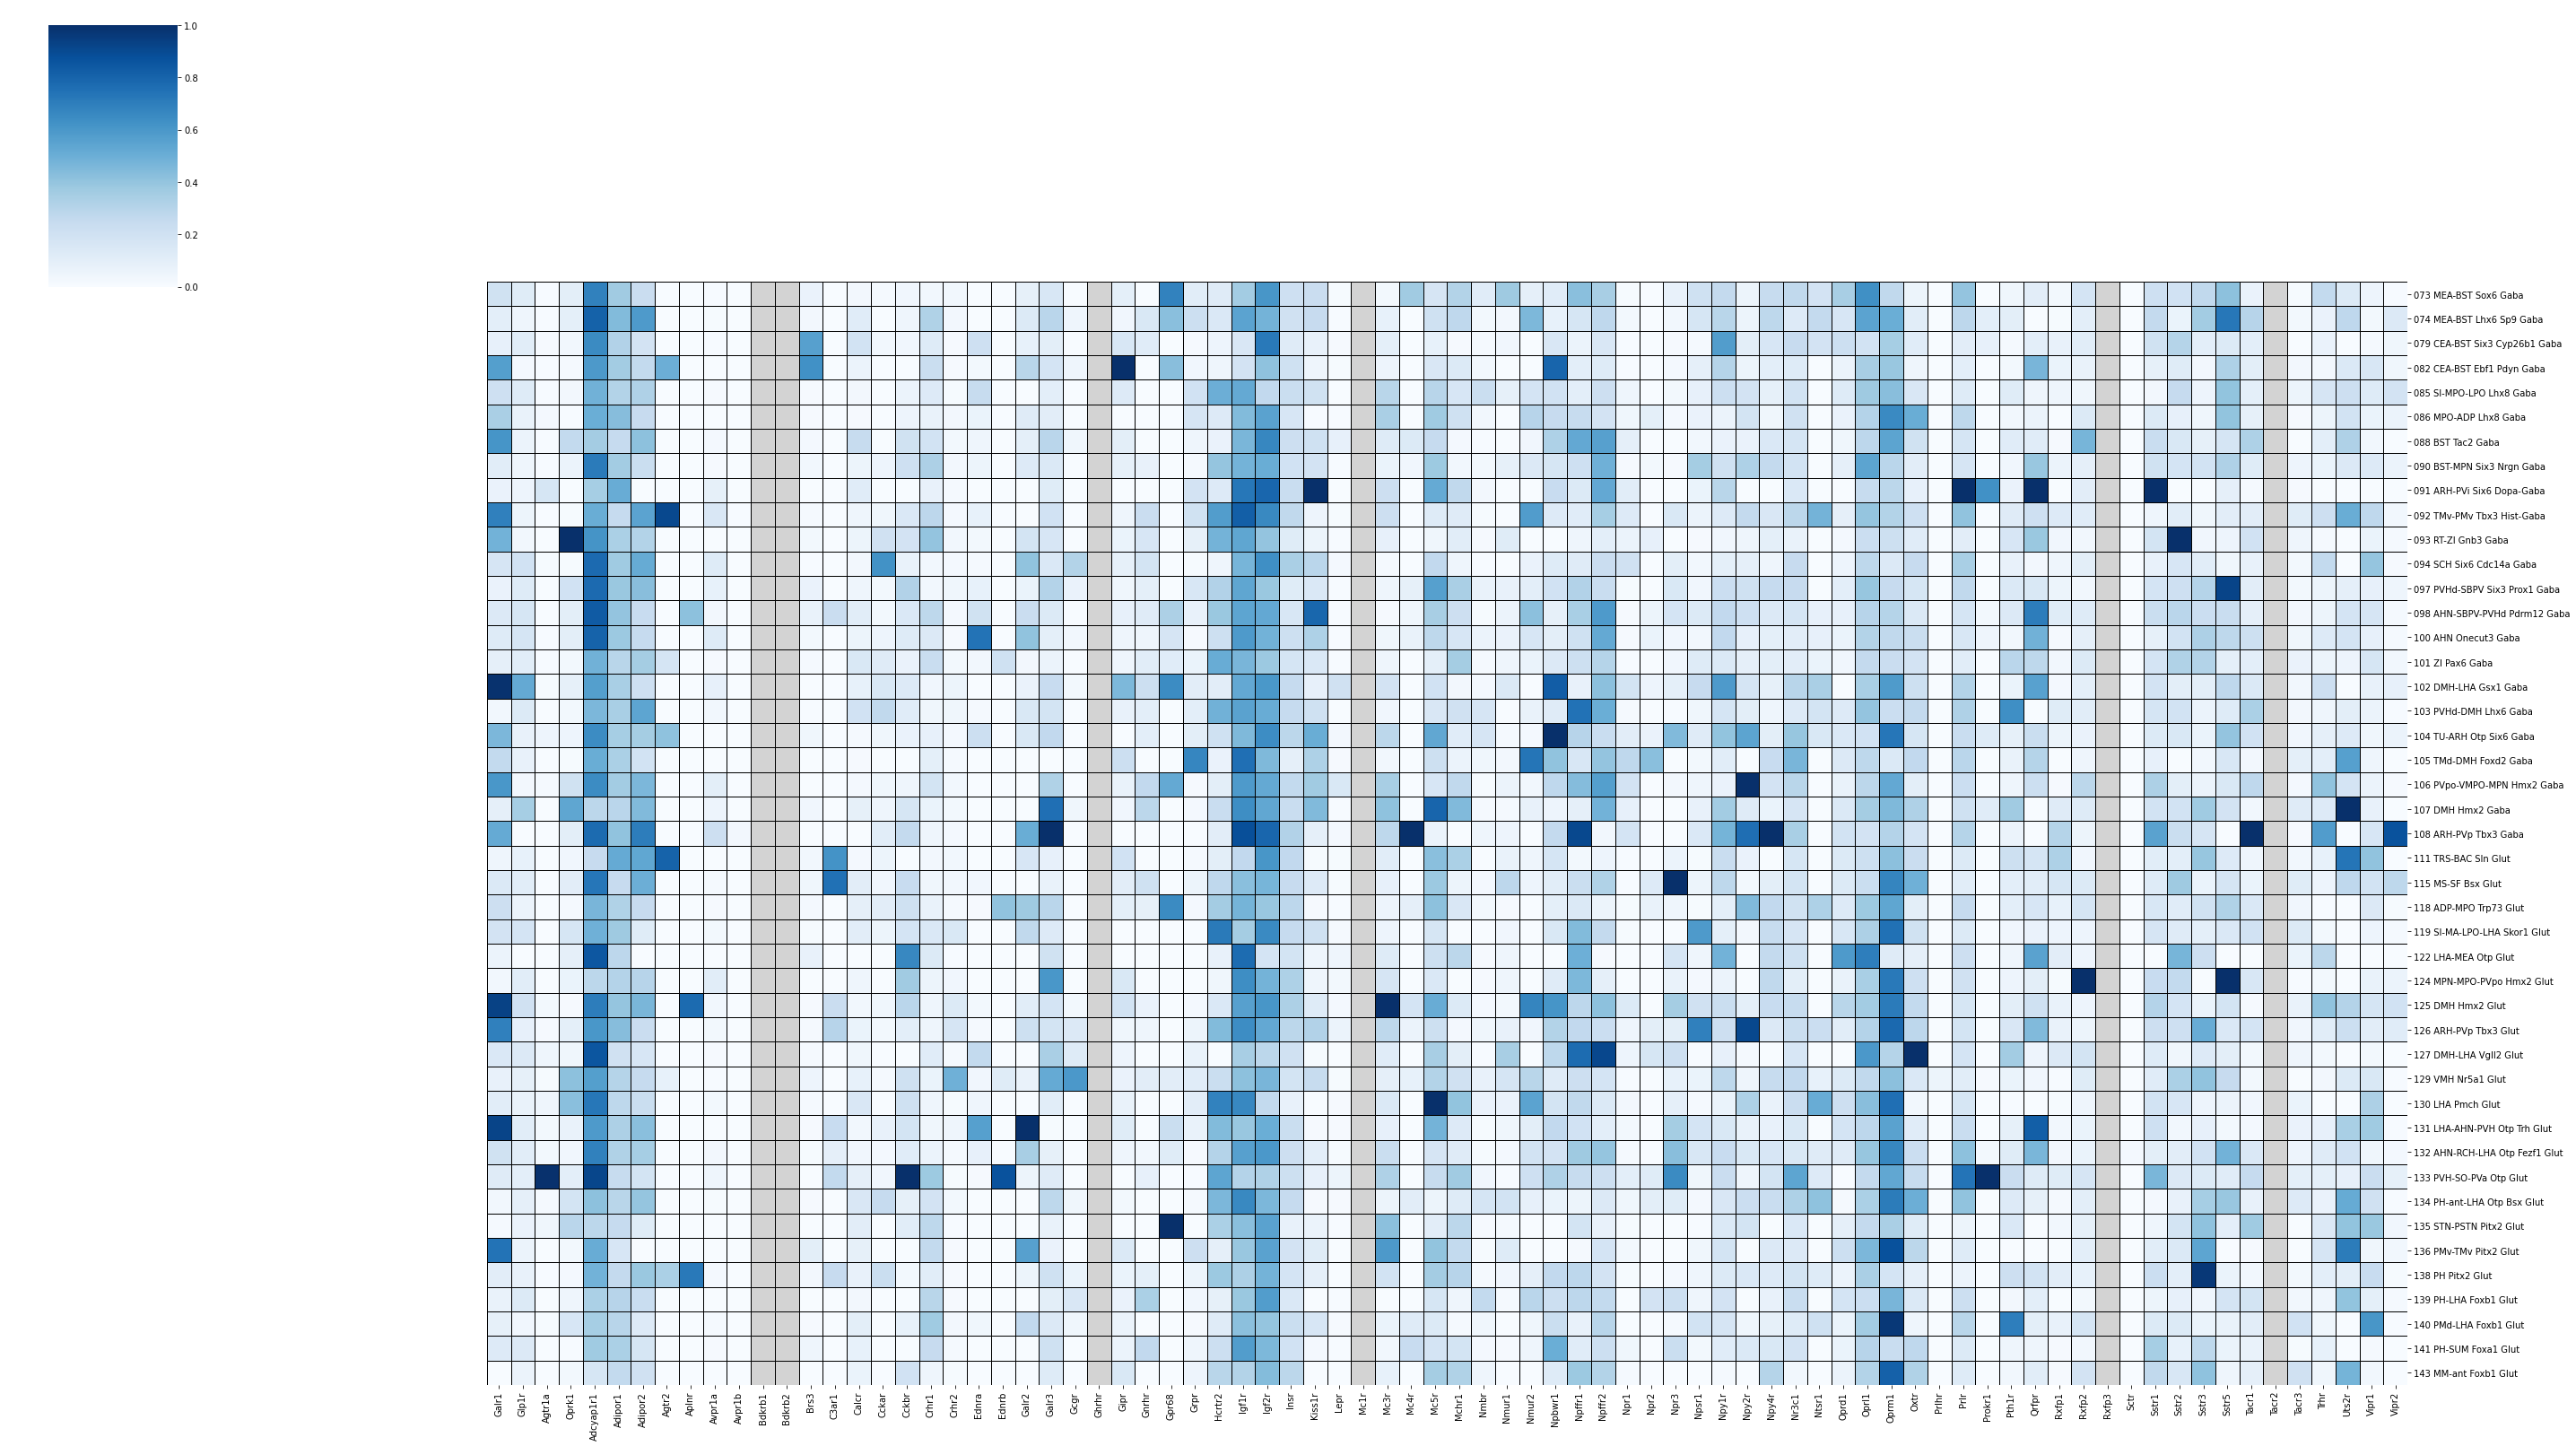

In [43]:
cmap = cm.get_cmap("Blues").copy()
cmap.set_bad(color="lightgrey") 
g = sns.clustermap(df_norm_npr, cmap = cmap,linewidth=.5,linecolor = 'black', row_cluster = False, col_cluster = False,
              figsize = (40,(40*df_norm_npr.shape[0])/df_norm_npr.shape[1]))
#plt.savefig('../../Figures/Figures_08022026/'+org+'_recep_mappedhypo_neurons_08042026.pdf')
#plt.savefig('../../Figures/Figures_08022026/'+org+'_recep_mappedhypo_neurons_08042026.svg')